# Assignment 1A — Numerical methods for quantum mechanics

## Preamble & shared tools

### Setup & imports

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Try to import scipy sparse modules for efficient matrix operations
# If scipy isn't available, we'll fall back to dense numpy arrays
try:
    import scipy.sparse as sps
    import scipy.sparse.linalg as spla
    scipy_available = True
except Exception:
    scipy_available = False

# Configure matplotlib defaults for better-looking plots
# Set figure size, enable grid, and adjust font size for readability
plt.rcParams.update({"figure.figsize": (6,4), "axes.grid": True, "grid.alpha": 0.35, "font.size": 11})

# Set numpy print options to show 8 decimal places and suppress scientific notation
np.set_printoptions(precision=8, suppress=True)


### Grid utilities and finite-difference operators

In [6]:
# Define a simple data class to hold grid information
# This makes it easy to pass around coordinate arrays and spacing together
@dataclass
class SpatialGrid:
    coordinates: np.ndarray  # The actual grid points
    grid_spacing: float      # The spacing between grid points

# Build the 3-point finite difference matrix for second derivatives
# This uses the standard centered difference formula: (f(x+h) - 2f(x) + f(x-h))/h²
def construct_laplacian_3pt(num_points: int, spacing: float, use_sparse: bool = True):
    # Main diagonal: -2 coefficient for each point
    diagonal = -2.0 * np.ones(num_points)
    # Off-diagonals: +1 coefficient for neighbors
    off_diagonal = 1.0 * np.ones(num_points - 1)
    
    # Use sparse format if scipy is available and requested (much faster for large matrices)
    if use_sparse and scipy_available:
        return sps.diags([off_diagonal, diagonal, off_diagonal], [-1, 0, 1], format="csc") / (spacing**2)
    
    # Fall back to dense numpy array if sparse isn't available
    laplacian = np.diag(diagonal) + np.diag(off_diagonal, 1) + np.diag(off_diagonal, -1)
    return laplacian / (spacing**2)

# [AI Attribution: ChatGPT 5.1 provided guidance on implementing the 5-point finite difference stencil,
#  including suggestions for the 4th-order stencil coefficients and sparse matrix construction approach.]

# Build the 5-point finite difference matrix for higher-order accuracy
# This gives 4th-order accuracy instead of 2nd-order, at the cost of more computation
def construct_laplacian_5pt(num_points: int, spacing: float, use_sparse: bool = True):
    # Coefficients for the 5-point stencil: [-1, 16, -30, 16, -1] / (12h²)
    diag_main = -30.0 * np.ones(num_points)
    diag_off1 = 16.0 * np.ones(num_points - 1)
    diag_off2 = -1.0 * np.ones(num_points - 2)
    
    if use_sparse and scipy_available:
        laplacian = sps.diags([diag_off2, diag_off1, diag_main, diag_off1, diag_off2], 
                              [-2, -1, 0, 1, 2], format="csc")
        return laplacian / (12.0 * spacing**2)
    
    # Dense version: build the full matrix
    laplacian = (np.diag(diag_off2, -2) + np.diag(diag_off1, -1) + np.diag(diag_main, 0) + 
                 np.diag(diag_off1, 1) + np.diag(diag_off2, 2))
    return laplacian / (12.0 * spacing**2)

# Assemble the full Hamiltonian matrix from kinetic and potential terms
# The kinetic term is the Laplacian times a prefactor (usually -0.5 or -1.0)
def assemble_hamiltonian(laplacian_matrix, potential_array, kinetic_coeff=-0.5):
    # Handle sparse matrices efficiently if available
    if scipy_available and sps.issparse(laplacian_matrix):
        return kinetic_coeff * laplacian_matrix + sps.diags(potential_array, 0, format="csc")
    # Dense matrix version
    return kinetic_coeff * laplacian_matrix + np.diag(potential_array)

# [AI Attribution: This eigenvalue solver function was implemented with assistance from ChatGPT 5.1.
#  AI helped guide the choice between scipy.sparse.linalg.eigsh (iterative Lanczos/Arnoldi method) 
#  for sparse matrices versus numpy.linalg.eigh (full diagonalization) for dense matrices, 
#  including parameter selection and sorting logic.]

# Solve for the k lowest eigenvalues and eigenvectors of a Hamiltonian
# Uses iterative methods for sparse matrices, full diagonalization for dense
# Note: parameter name 'k' matches scipy's eigsh interface

def compute_lowest_eigenstates(hamiltonian, k=10, which="SA"):
    if scipy_available and sps.issparse(hamiltonian):
        # Use Lanczos/Arnoldi method for sparse matrices (much faster)
        eigenvalues, eigenvectors = spla.eigsh(hamiltonian, k=k, which=which)
        # Sort by eigenvalue (eigsh sometimes returns unsorted)
        sort_idx = np.argsort(eigenvalues)
        return eigenvalues[sort_idx], eigenvectors[:, sort_idx]
    
    # Full diagonalization for dense matrices (slower but works for small systems)
    eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian)
    # Return only the k lowest states
    sort_idx = np.argsort(eigenvalues)[:k]
    return eigenvalues[sort_idx], eigenvectors[:, sort_idx]

# Normalize a wavefunction so that ∫|ψ|²dx = 1
# Uses trapezoidal integration to compute the norm
def normalize_wavefunction(wavefunction: np.ndarray, grid: SpatialGrid):
    # Compute the norm using trapezoidal rule
    norm = math.sqrt(np.trapz(np.abs(wavefunction)**2, grid.coordinates))
    # Divide by norm, but avoid division by zero
    return wavefunction / (norm if norm > 0 else 1.0)

# Compute overlap matrix between multiple wavefunctions
# Returns S[i,j] = ∫ψ*ᵢ ψⱼ dx, which should be δᵢⱼ for orthonormal states
def compute_overlap_matrix(wavefunctions: np.ndarray, grid: SpatialGrid):
    num_states = wavefunctions.shape[1]
    overlap_matrix = np.empty((num_states, num_states), dtype=complex)
    
    # Compute all pairwise overlaps
    for i in range(num_states):
        for j in range(num_states):
            # Integrate the product of wavefunction i and j
            overlap_matrix[i, j] = np.trapz(np.conj(wavefunctions[:, i]) * wavefunctions[:, j], grid.coordinates)
    
    return overlap_matrix

### Dirichlet boundary conditions and potentials

In [8]:
# === Dirichlet (interior-point) operators ===
# These functions build operators that act only on interior grid points,
# automatically enforcing zero boundary conditions at the edges

def construct_dirichlet_laplacian(grid: SpatialGrid):
    """
    Second-derivative matrix acting only on INTERIOR points (Dirichlet BCs).
    Size: (N-2) x (N-2), corresponding to coordinates[1:-1].
    This enforces ψ(0) = ψ(L) = 0 automatically.
    """
    num_points = grid.coordinates.size
    # Main diagonal: -2 coefficient for each interior point
    diagonal = -2.0 * np.ones(num_points - 2)
    # Off-diagonals: +1 for neighbors (one less than diagonal)
    off_diagonal = 1.0 * np.ones(num_points - 3)
    
    if scipy_available:
        # Build sparse matrix for efficiency
        laplacian_int = sps.diags([off_diagonal, diagonal, off_diagonal], [-1, 0, 1], format="csc") / (grid.grid_spacing**2)
    else:
        # Dense version as fallback
        laplacian_int = (np.diag(diagonal) + np.diag(off_diagonal, 1) + np.diag(off_diagonal, -1)) / (grid.grid_spacing**2)
    
    return laplacian_int

def assemble_dirichlet_hamiltonian(grid: SpatialGrid, potential):
    """
    Hamiltonian with Dirichlet BC: acts only on interior points 1..N-2.
    Returns H_int of shape (N-2, N-2) and the interior potential V_int.
    Uses the standard kinetic prefactor -1/2 for quantum mechanics.
    """
    # Build the Laplacian for interior points only
    laplacian_int = construct_dirichlet_laplacian(grid)
    # Extract potential values at interior points (exclude boundaries)
    potential_int = np.asarray(potential)[1:-1]
    
    if scipy_available and sps.issparse(laplacian_int):
        # Sparse matrix assembly
        hamiltonian_int = (-0.5) * laplacian_int + sps.diags(potential_int, 0, format="csc")
    else:
        # Dense matrix assembly
        hamiltonian_int = (-0.5) * laplacian_int + np.diag(potential_int)
    
    return hamiltonian_int, potential_int


# --- Hydrogen effective potential in standard atomic units ---
# The radial Schrödinger equation for hydrogen has the form:
# H = -(1/2) d²/dr² + V_eff(r)
# where V_eff(r) = -1/r + ℓ(ℓ+1)/(2r²)
# This gives the exact energies E_n = -1/(2n²) for ℓ = 0
SMALL_R = 1e-14  # Small number to avoid division by zero at r=0

def hydrogen_effective_potential(radial_coords, angular_momentum=0):
    """
    Compute the effective potential for hydrogen atom radial equation.
    Includes both the Coulomb term (-1/r) and the centrifugal barrier.
    """
    # Avoid division by zero by replacing very small r values
    r_safe = np.maximum(np.asarray(radial_coords, float), SMALL_R)
    # Coulomb term: -1/r
    coulomb = -1.0 / r_safe
    # Centrifugal barrier: ℓ(ℓ+1)/(2r²)
    centrifugal = 0.5 * angular_momentum * (angular_momentum + 1) / (r_safe**2)
    return coulomb + centrifugal

### Sanity checks for finite–difference operators 

Running finite–difference sanity checks...
All finite-difference sanity checks passed.


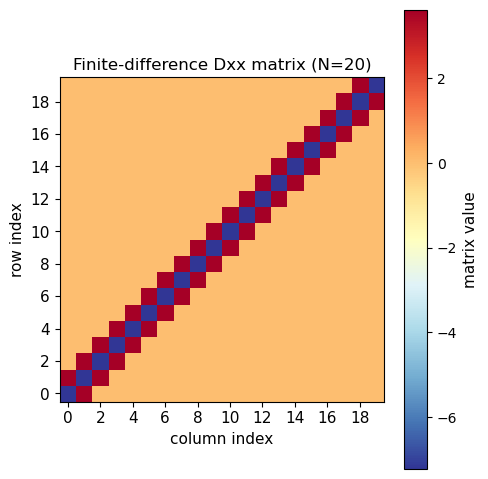

In [10]:
# This cell verifies that our finite difference operators are constructed correctly
# by checking their structure and properties

print("Running finite–difference sanity checks...")

# Define QHO potential inline (self-contained, doesn't require Cell 10)
# Standard harmonic oscillator potential: V(x) = (1/2) mω²x²
# In our units, m=ω=1, so V(x) = x²/2
def qho_potential(x):
    return 0.5 * x**2

# Set up a small test grid for verification
# Create grid inline (self-contained, doesn't require create_uniform_grid to be defined)
num_points_test = 20
x_min_test, x_max_test = -5.0, 5.0
coordinates_test = np.linspace(x_min_test, x_max_test, num_points_test, dtype=float)
grid_spacing = coordinates_test[1] - coordinates_test[0]
grid_test = SpatialGrid(coordinates=coordinates_test, grid_spacing=grid_spacing)

# Build second derivative matrix using our 3-point stencil
laplacian_test = construct_laplacian_3pt(num_points_test, grid_spacing)

# Convert to dense if needed (for easier inspection)
# Sparse matrices need to be converted to dense for diagonal extraction
if scipy_available and sps.issparse(laplacian_test):
    dense_matrix = np.array(laplacian_test.todense())
else:
    dense_matrix = laplacian_test

# Expected stencils for 3-point finite difference
# Main diagonal: -2/h² coefficient
expected_main_diagonal = -2.0 * np.ones(num_points_test) / grid_spacing**2
# Off-diagonals: +1/h² coefficient
expected_off_diagonal = 1.0 * np.ones(num_points_test - 1) / grid_spacing**2

# Check tridiagonal structure
# The matrix should have the correct values on main diagonal and off-diagonals
tridiagonal_ok = (
    np.allclose(np.diag(dense_matrix), expected_main_diagonal) and
    np.allclose(np.diag(dense_matrix, +1), expected_off_diagonal) and
    np.allclose(np.diag(dense_matrix, -1), expected_off_diagonal)
)
assert tridiagonal_ok, "Finite-difference stencil is not tridiagonal as expected."

# Test potential evaluation
# The potential should be a 1D array (diagonal when embedded in Hamiltonian)
potential_test = qho_potential(grid_test.coordinates)
potential_is_diagonal = (
    np.ndim(potential_test) == 1 or
    np.allclose(np.diag(np.diag(potential_test)), potential_test)
)
assert potential_is_diagonal, "Potential vector must be diagonal when embedded via diag(V)."

# Test Dirichlet Hamiltonian assembly
# The interior Hamiltonian should have size (N-2) x (N-2)
hamiltonian_int_test, potential_int_test = assemble_dirichlet_hamiltonian(grid_test, potential_test)
shape_ok = (hamiltonian_int_test.shape == (num_points_test - 2, num_points_test - 2))
assert shape_ok, "Dirichlet interior Hamiltonian has wrong shape."

print("All finite-difference sanity checks passed.")

# === Visualisation of tri–diagonal finite-difference stencil (high-quality) ===
# Visualize the structure of the finite difference matrix
# This helps verify the tridiagonal pattern visually

num_points_vis = dense_matrix.shape[0]  # auto-detect matrix size (e.g. 20)

plt.figure(figsize=(5, 5))

# Display the matrix as an image
# The tridiagonal structure should be clearly visible
# Using a custom colormap that matches our pink/blue scheme
plt.imshow(
    dense_matrix,
    cmap="RdYlBu_r",  # Red-Yellow-Blue reversed (pink/red to blue tones)
    origin="lower",
    aspect="equal"  # square pixels → true visual tridiagonal
)

plt.title(f"Finite-difference Dxx matrix (N={num_points_vis})", fontsize=12)
colorbar = plt.colorbar(label="matrix value")
colorbar.ax.tick_params(labelsize=10)

# Axis labels
plt.xlabel("column index", fontsize=11)
plt.ylabel("row index", fontsize=11)

# Cleaner ticks (every 2 indices for readability)
tick_step = max(1, num_points_vis // 10)
plt.xticks(np.arange(0, num_points_vis, tick_step))
plt.yticks(np.arange(0, num_points_vis, tick_step))

# Remove gridlines for cleaner visualization
plt.grid(False)

plt.tight_layout()
plt.show()

## 1. Quantum Harmonic Oscillator (QHO)

### 1.1 QHO helper functions

In [13]:
# QHO helper functions for setting up and solving the quantum harmonic oscillator

# Safety check: define the QHO potential if it wasn't defined earlier
# This prevents errors if cells are run out of order
try:
    qho_potential
except NameError:
    def qho_potential(x): 
        # Standard harmonic oscillator potential: V(x) = (1/2) mω²x²
        # In our units, m=ω=1, so V(x) = x²/2
        return 0.5 * x**2

def create_uniform_grid(num_points=1200, x_min=-8.0, x_max=8.0):
    """
    Create a uniform 1D grid on [x_min, x_max] with num_points points.
    Returns a SpatialGrid object containing coordinates and spacing.
    """
    coordinates = np.linspace(x_min, x_max, num_points, dtype=float)
    spacing = (x_max - x_min) / (num_points - 1)
    return SpatialGrid(coordinates=coordinates, grid_spacing=spacing)

def compute_qho_eigenstates(num_points=1200, box_halfwidth=8.0, num_states=10):
    """
    Quantum harmonic oscillator on [-box_halfwidth, box_halfwidth] using 3-point FD with Dirichlet BCs.
    Returns grid, interior Hamiltonian, potential samples, eigenvalues, eigenvectors.
    """
    # Create the spatial grid
    grid = create_uniform_grid(num_points, -box_halfwidth, box_halfwidth)
    # Evaluate potential at all grid points
    potential_samples = qho_potential(grid.coordinates)
    # Build Hamiltonian with Dirichlet boundary conditions
    hamiltonian_int, _ = assemble_dirichlet_hamiltonian(grid, potential_samples)
    # Solve for the lowest num_states eigenvalues and eigenvectors
    eigenvalues, eigenfunctions_int = compute_lowest_eigenstates(hamiltonian_int, k=num_states)

    # Reconstruct full wavefunctions (zero at endpoints) for plotting/normalization
    # Start with zeros everywhere, then fill in interior points
    eigenfunctions_full = np.zeros((grid.coordinates.size, num_states), dtype=complex)
    eigenfunctions_full[1:-1, :] = eigenfunctions_int

    # Normalize each wavefunction and fix sign convention
    # We choose the sign so that ψ is positive at the center
    center_index = len(grid.coordinates) // 2
    for j in range(eigenfunctions_full.shape[1]):
        eigenfunctions_full[:, j] = normalize_wavefunction(eigenfunctions_full[:, j], grid)
        # Flip sign if wavefunction is negative at center (convention)
        if eigenfunctions_full[center_index, j] < 0:
            eigenfunctions_full[:, j] *= -1
    
    # Convert to real (eigenvectors should be real for this symmetric problem)
    eigenfunctions_full = eigenfunctions_full.real
    return grid, hamiltonian_int, potential_samples, eigenvalues, eigenfunctions_full

def visualize_qho_states(grid, eigenvalues, eigenfunctions, potential, num_show=10):
    """
    Plot potential and first num_show eigenstates (offset by their energies).
    This makes it easy to see how the wavefunctions relate to the potential well.
    """
    fig, ax = plt.subplots()
    # Plot the potential curve
    ax.plot(grid.coordinates, potential, lw=1.0, label="V(x)")
    # Plot each eigenstate, shifted up by its energy
    for j in range(min(num_show, len(eigenvalues))):
        ax.plot(grid.coordinates, eigenfunctions[:, j] + eigenvalues[j], 
                lw=1.0, label=f"ψ{j}(x)+E{j}")
    ax.set_xlabel("x")
    ax.set_ylabel("Energy / amplitude")
    ax.set_title("QHO: first eigenstates (offset by E)")
    ax.set_ylim(0, 11)
    ax.legend(loc='lower left', fontsize=9)
    plt.show()

### 1.2 QHO: energies & first 10 states

=== QHO energies ===


,Level n,E_numeric,E_analytic,ΔE = E_numeric - E_analytic
0,0,0.49999538,0.50000000,-4.62e-06
1,1,1.49997691,1.50000000,-2.31e-05
2,2,2.49993996,2.50000000,-6.00e-05
3,3,3.49988453,3.50000000,-1.15e-04
4,4,4.49981063,4.50000000,-1.89e-04
5,5,5.49971825,5.50000000,-2.82e-04
6,6,6.49960739,6.50000000,-3.93e-04
7,7,7.49947806,7.50000000,-5.22e-04
8,8,8.49933024,8.50000000,-6.70e-04
9,9,9.49916395,9.50000000,-8.36e-04


Max |ΔE| = 0.0008360470559676259

=== QHO edge amplitudes (max |ψ| in outer 5% of box) ===


,Level n,max edge |ψ|
0,0,1.09e-12
1,1,1.13e-11
2,2,8.24e-11
3,3,4.87e-10
4,4,2.47e-09
5,5,1.11e-08
6,6,4.51e-08
7,7,1.68e-07
8,8,5.77e-07
9,9,1.85e-06


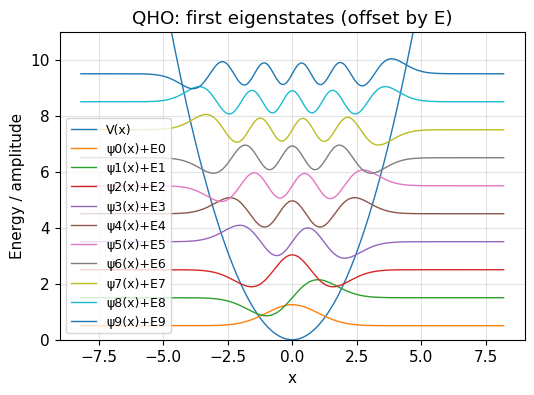

Saved: /Users/sammybouchebaba/Downloads/QHO_first_eigenstates_offset_by_E.png


<Figure size 600x400 with 0 Axes>

In [15]:
# Compute QHO eigenstates and compare with exact analytical results
# The exact energies are E_n = n + 0.5 for n = 0, 1, 2, ...
qho_grid, qho_hamiltonian, qho_potential_samples, qho_eigenvalues, qho_eigenfunctions = compute_qho_eigenstates(num_points=1350, box_halfwidth=8.2, num_states=10)

# Calculate exact eigenvalues for comparison
exact_qho_eigenvalues = np.array([n + 0.5 for n in range(len(qho_eigenvalues))], float)

# --- Compare numeric vs analytic energies and show as a nice table ---
import pandas as pd
from IPython.display import display

# Build DataFrame for energy comparison
qho_energies_df = pd.DataFrame({
    "Level n": np.arange(len(qho_eigenvalues)),
    "E_numeric": qho_eigenvalues,
    "E_analytic": exact_qho_eigenvalues,
    "ΔE = E_numeric - E_analytic": qho_eigenvalues - exact_qho_eigenvalues
})

print("=== QHO energies ===")
display(
    qho_energies_df.style.format({
        "E_numeric": "{:.8f}",
        "E_analytic": "{:.8f}",
        "ΔE = E_numeric - E_analytic": "{:+.2e}"
    })
)

# Calculate the maximum error across all computed states
max_error = float(np.max(np.abs(qho_eigenvalues - exact_qho_eigenvalues)))
print("Max |ΔE| =", max_error)

# Check edge amplitudes to verify boundary conditions are satisfied
# The wavefunctions should be very small near the box edges
edge_shell_fraction = 0.05
num_shell_points = max(1, int(edge_shell_fraction * (qho_grid.coordinates.size - 2)))

# Compute edge amplitudes for all states
edge_amplitudes = []
for n in range(len(qho_eigenvalues)):
    wavefunction = qho_eigenfunctions[:, n]
    # Check left edge (excluding the boundary point which is exactly zero)
    left_edge = np.abs(wavefunction[1:1+num_shell_points])
    # Check right edge
    right_edge = np.abs(wavefunction[-1-num_shell_points:-1])
    # Take the maximum amplitude in either edge region
    max_edge_amplitude = max(left_edge.max(), right_edge.max())
    edge_amplitudes.append(max_edge_amplitude)

# Build DataFrame for edge amplitudes
qho_edge_amplitudes_df = pd.DataFrame({
    "Level n": np.arange(len(qho_eigenvalues)),
    "max edge |ψ|": edge_amplitudes
})

print("\n=== QHO edge amplitudes (max |ψ| in outer 5% of box) ===")
display(
    qho_edge_amplitudes_df.style.format({
        "max edge |ψ|": "{:.2e}"
    })
)

# Visualize the eigenstates
visualize_qho_states(qho_grid, qho_eigenvalues, qho_eigenfunctions, qho_potential_samples, num_show=10)

# Save plot to Downloads folder
import os
import re

downloads_path = os.path.expanduser("~/Downloads")
title = "QHO: first eigenstates (offset by E)"
filename = re.sub(r'[^\w\s-]', '', title).strip().replace(' ', '_') + '.png'
filepath = os.path.join(downloads_path, filename)

# Get the current figure (created by visualize_qho_states)
fig_qho = plt.gcf()
fig_qho.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath}")

### 1.3 Parity check for QHO eigenstates

In [17]:
# === Parity check for QHO eigenstates (DataFrame version) ===
# The QHO eigenfunctions should have definite parity: ψ_n(-x) = (-1)^n ψ_n(x)
# This cell verifies that our numerical eigenfunctions satisfy this symmetry property

parity_errors = []

# Reversed grid indices: x -> -x
# For a symmetric grid centered at 0, reversing the coordinates gives -x
reversed_eigenfunctions = qho_eigenfunctions[::-1, :]  # same shape as qho_eigenfunctions, but reversed along x

# Check parity for each eigenstate
for n in range(len(qho_eigenvalues)):
    # Expected: ψ_n(-x) = (-1)^n ψ_n(x)
    expected_parity = ((-1)**n) * qho_eigenfunctions[:, n]
    # Compute the error: ||ψ(-x) - (-1)^n ψ(x)||
    parity_error = np.linalg.norm(reversed_eigenfunctions[:, n] - expected_parity)
    parity_errors.append(parity_error)

# Build a DataFrame for nicer display
parity_df = pd.DataFrame({
    "n (level index)": np.arange(len(qho_eigenvalues)),
    "parity error  ||ψ(-x) − (-1)^n ψ(x)||": parity_errors
})

# Formatting: scientific notation for the error column
parity_df_styled = parity_df.style.format({
    "parity error  ||ψ(-x) − (-1)^n ψ(x)||": "{:.2e}"
})

print("QHO parity check (||ψ(-x) − (-1)^n ψ(x)||):")
display(parity_df_styled)

QHO parity check (||ψ(-x) − (-1)^n ψ(x)||):


,n (level index),parity error ||ψ(-x) − (-1)^n ψ(x)||
0,0,1.47e-12
1,1,7.51e-12
2,2,7.55e-12
3,3,3.49e-12
4,4,4.28e-12
5,5,3.33e-12
6,6,3.72e-12
7,7,5.03e-12
8,8,1.95e-12
9,9,6.78e-12


### 1.4 QHO: ground-state error vs N and box size

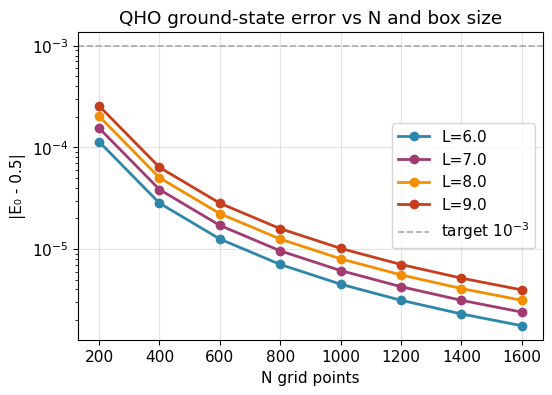

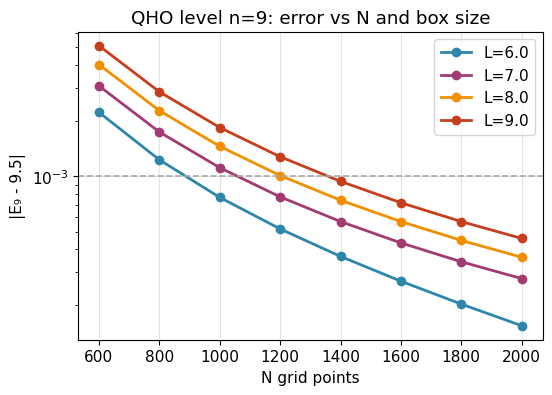

Saved: /Users/sammybouchebaba/Downloads/QHO_ground-state_error_vs_N_and_box_size.png
Saved: /Users/sammybouchebaba/Downloads/QHO_level_n9_error_vs_N_and_box_size.png


In [19]:
# Function to compute the energy error for a specific QHO energy level
# This measures how far our numerical result deviates from the exact analytical value
def compute_qho_energy_error(num_points, box_halfwidth, level=0):
    # Create the spatial grid for the QHO problem
    grid = create_uniform_grid(num_points, -box_halfwidth, box_halfwidth)
    # Evaluate the harmonic oscillator potential at all grid points
    potential_samples = qho_potential(grid.coordinates)
    # Build the Hamiltonian with Dirichlet boundary conditions
    hamiltonian_int, _ = assemble_dirichlet_hamiltonian(grid, potential_samples)
    # Solve for the lowest (level+1) eigenvalues to get the desired level
    eigenvalues, _ = compute_lowest_eigenstates(hamiltonian_int, k=level+1)
    # Return the absolute error from the exact value E_n = n + 0.5
    return abs(eigenvalues[level] - (level + 0.5))

# Set up grid point ranges for convergence study
# We'll test different numbers of grid points to see how error decreases
point_counts = np.linspace(200, 1600, 8, dtype=int)
# Test different box sizes to see how boundary effects matter
box_sizes = [6.0, 7.0, 8.0, 9.0]

# Define a custom color scheme for the plots
plot_colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']  # Blue, Purple, Orange, Red

# Plot 1: Ground state (n=0) error vs number of grid points
fig0, ax0 = plt.subplots()
for i, L in enumerate(box_sizes):
    # Compute errors for each grid resolution
    errors = [compute_qho_energy_error(N, L, level=0) for N in point_counts]
    ax0.plot(point_counts, errors, marker="o", label=f"L={L:.1f}", 
             color=plot_colors[i], linewidth=2, markersize=6)
# Add a reference line showing our target accuracy
ax0.axhline(1e-3, ls="--", color="darkgrey", lw=1.2, label=r"target $10^{-3}$")
ax0.set_yscale("log")
ax0.set_xlabel("N grid points")
ax0.set_ylabel("|E₀ - 0.5|")
ax0.set_title("QHO ground-state error vs N and box size")
ax0.legend()
plt.show()

# Plot 2: Higher excited state (n=9) error vs number of grid points
# Higher states need more grid points for the same accuracy
point_counts_dense = np.linspace(600, 2000, 8, dtype=int)
fig9, ax9 = plt.subplots()
for i, L in enumerate(box_sizes):
    # Compute errors for the 9th excited state
    errors = [compute_qho_energy_error(N, L, level=9) for N in point_counts_dense]
    ax9.plot(point_counts_dense, errors, marker="o", label=f"L={L:.1f}",
             color=plot_colors[i], linewidth=2, markersize=6)
ax9.axhline(1e-3, ls="--", color="darkgrey", lw=1.2)
ax9.set_yscale("log")
ax9.set_xlabel("N grid points")
ax9.set_ylabel("|E₉ - 9.5|")
ax9.set_title("QHO level n=9: error vs N and box size")
ax9.legend()
plt.show()

# Save plots to Downloads folder
import os
import re

downloads_path = os.path.expanduser("~/Downloads")

# Save first plot
title1 = "QHO ground-state error vs N and box size"
filename1 = re.sub(r'[^\w\s-]', '', title1).strip().replace(' ', '_') + '.png'
filepath1 = os.path.join(downloads_path, filename1)
fig0.savefig(filepath1, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath1}")

# Save second plot
title2 = "QHO level n=9: error vs N and box size"
filename2 = re.sub(r'[^\w\s-]', '', title2).strip().replace(' ', '_') + '.png'
filepath2 = os.path.join(downloads_path, filename2)
fig9.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")

### 1.5 QHO: order-of-accuracy (error vs grid spacing)

Order-of-accuracy fit for QHO ground state (E0):
  log(error) ≈ 2.000 * log(Δx) + -3.465
  → estimated order p ≈ 2.000 (expected p = 2 for 3-point stencil)


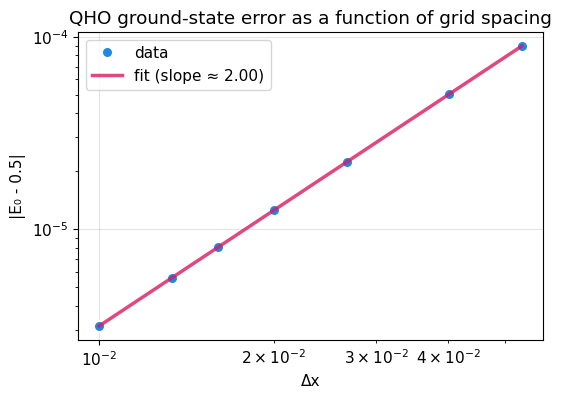

Saved: /Users/sammybouchebaba/Downloads/QHO_ground-state_error_vs_grid_spacing_log-log.png


In [21]:
# === QHO: demonstrate 2nd-order accuracy explicitly (error vs Δx) ===
# This cell shows that our finite difference method has 2nd-order convergence
# by plotting error vs grid spacing on a log-log scale

# Fix the box size and vary the number of grid points
box_halfwidth_acc = 8.0
point_counts_acc = np.array([300, 400, 600, 800, 1000, 1200, 1600], dtype=int)

# Calculate grid spacing for each resolution
# Grid spacing = total box width / (number of points - 1)
grid_spacings = 2.0 * box_halfwidth_acc / (point_counts_acc - 1)
# Compute errors for each grid resolution
errors = np.array([compute_qho_energy_error(N, box_halfwidth_acc, level=0) for N in point_counts_acc])

# Fit a power law: error ~ (Δx)^p
# Taking logs: log(error) = p * log(Δx) + constant
log_spacing = np.log(grid_spacings)
log_error = np.log(errors)
slope, intercept = np.polyfit(log_spacing, log_error, 1)

print("Order-of-accuracy fit for QHO ground state (E0):")
print(f"  log(error) ≈ {slope:.3f} * log(Δx) + {intercept:.3f}")
print(f"  → estimated order p ≈ {slope:.3f} (expected p = 2 for 3-point stencil)")

# Plot log-log with fitted line to visualize the power-law relationship
fig_qho_conv, ax = plt.subplots()
# Data points with custom color and styling
ax.plot(grid_spacings, errors, "o", label="data", 
        color="#1E88E5", markersize=8, markeredgewidth=1.5, markeredgecolor="white", linewidth=0)
# Overlay the fitted power law with different color
ax.plot(grid_spacings, np.exp(intercept + slope * log_spacing), "-", 
        label=f"fit (slope ≈ {slope:.2f})", color="#D81B60", linewidth=2.5, alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Δx")
ax.set_ylabel("|E₀ - 0.5|")
ax.set_title("QHO ground-state error as a function of grid spacing")
ax.legend()
plt.show()

# Save plot to Downloads folder
import os
import re

downloads_path = os.path.expanduser("~/Downloads")
title = "QHO ground-state error vs grid spacing (log-log)"
filename = re.sub(r'[^\w\s-]', '', title).strip().replace(' ', '_') + '.png'
filepath = os.path.join(downloads_path, filename)
fig_qho_conv.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath}")

### 1.6 QHO: 3-pt vs 5-pt FD comparison

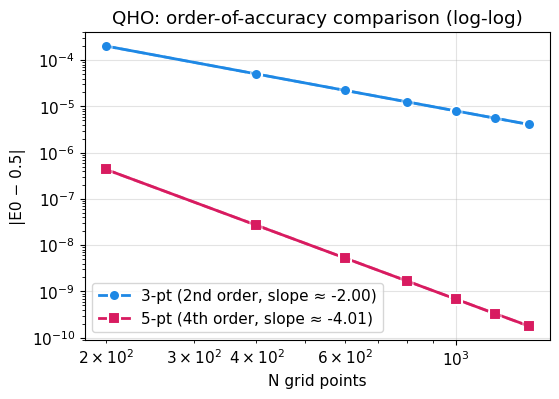

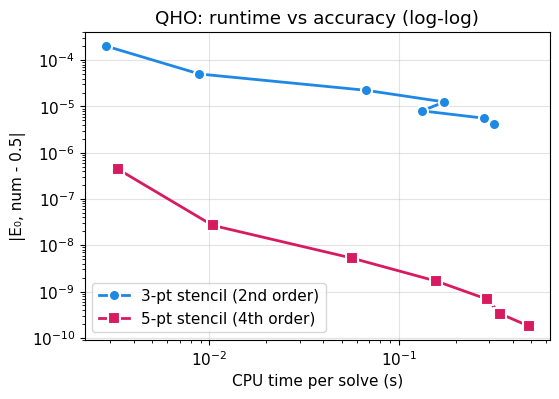

Saved: /Users/sammybouchebaba/Downloads/QHO_order-of-accuracy_comparison_log-log.png
Saved: /Users/sammybouchebaba/Downloads/QHO_runtime_vs_accuracy_log-log.png


In [23]:
import time

import time

# Compare 3-point and 5-point finite difference stencils
# The 5-point stencil should give 4th-order accuracy vs 2nd-order for 3-point
def plot_qho_stencil_comparison():
    # Test a range of grid resolutions
    point_counts = np.linspace(200, 1400, 7, dtype=int)
    box_halfwidth = 8.0
    errors_3pt, errors_5pt, times_3pt, times_5pt = [], [], [], []
    
    for N in point_counts:
        # Set up grid and potential
        grid = create_uniform_grid(N, -box_halfwidth, box_halfwidth)
        potential_samples = qho_potential(grid.coordinates)
        
        # 3-point stencil with Dirichlet BCs (consistent with rest of QHO code)
        hamiltonian_3pt_int, _ = assemble_dirichlet_hamiltonian(grid, potential_samples)
        t0 = time.perf_counter()
        eigenvalues_3pt, _ = compute_lowest_eigenstates(hamiltonian_3pt_int, k=1)
        times_3pt.append(time.perf_counter() - t0)
        errors_3pt.append(abs(eigenvalues_3pt[0] - 0.5))
        
        # 5-point stencil (full grid - no Dirichlet version implemented)
        # Build the 5-point Laplacian on the full grid
        laplacian_5pt = construct_laplacian_5pt(N, grid.grid_spacing, use_sparse=True)
        # Assemble full Hamiltonian (not just interior)
        hamiltonian_5pt = assemble_hamiltonian(laplacian_5pt, potential_samples, kinetic_coeff=-0.5)
        t0 = time.perf_counter()
        eigenvalues_5pt, _ = compute_lowest_eigenstates(hamiltonian_5pt, k=1)
        times_5pt.append(time.perf_counter() - t0)
        errors_5pt.append(abs(eigenvalues_5pt[0] - 0.5))
    
    # Plot 1: Error vs N (order-of-accuracy comparison)
    # Fit straight lines on log-log scale for both stencils to extract convergence orders
    log_N = np.log(point_counts)
    log_err_3pt = np.log(errors_3pt)
    log_err_5pt = np.log(errors_5pt)
    slope_3pt, intercept_3pt = np.polyfit(log_N, log_err_3pt, 1)
    slope_5pt, intercept_5pt = np.polyfit(log_N, log_err_5pt, 1)
    
    # Custom colors for 3-pt and 5-pt stencils
    color_3pt = "#1E88E5"  # Blue
    color_5pt = "#D81B60"  # Pink/Magenta
    
    fig1, ax1 = plt.subplots()
    ax1.loglog(point_counts, errors_3pt, marker="o", label=f"3-pt (2nd order, slope ≈ {slope_3pt:.2f})",
              color=color_3pt, markersize=8, markeredgewidth=1.5, markeredgecolor="white", linewidth=2)
    ax1.loglog(point_counts, errors_5pt, marker="s", label=f"5-pt (4th order, slope ≈ {slope_5pt:.2f})",
              color=color_5pt, markersize=8, markeredgewidth=1.5, markeredgecolor="white", linewidth=2)
    # Add fitted lines to show the power-law behavior
    ax1.loglog(point_counts, np.exp(intercept_3pt + slope_3pt * log_N), "--", 
              alpha=0.6, color=color_3pt, linewidth=2)
    ax1.loglog(point_counts, np.exp(intercept_5pt + slope_5pt * log_N), "--", 
              alpha=0.6, color=color_5pt, linewidth=2)
    ax1.set_xlabel("N grid points")
    ax1.set_ylabel("|E0 − 0.5|")
    ax1.set_title("QHO: order-of-accuracy comparison (log-log)")
    ax1.legend()
    plt.show()
    
    # Plot 2: Error vs CPU time (efficiency comparison)
    # This shows the trade-off between accuracy and computational cost
    fig2, ax2 = plt.subplots()
    ax2.loglog(times_3pt, errors_3pt, marker="o", label="3-pt stencil (2nd order)",
              color=color_3pt, markersize=8, markeredgewidth=1.5, markeredgecolor="white", linewidth=2)
    ax2.loglog(times_5pt, errors_5pt, marker="s", label="5-pt stencil (4th order)",
              color=color_5pt, markersize=8, markeredgewidth=1.5, markeredgecolor="white", linewidth=2)
    ax2.set_xlabel("CPU time per solve (s)")
    ax2.set_ylabel("|E₀, num - 0.5|")
    ax2.set_title("QHO: runtime vs accuracy (log-log)")
    ax2.legend()
    plt.show()
    
    # Save plots to Downloads folder
    import os
    import re
    
    downloads_path = os.path.expanduser("~/Downloads")
    
    # Save first plot
    title1 = "QHO: order-of-accuracy comparison (log-log)"
    filename1 = re.sub(r'[^\w\s-]', '', title1).strip().replace(' ', '_') + '.png'
    filepath1 = os.path.join(downloads_path, filename1)
    fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath1}")
    
    # Save second plot
    title2 = "QHO: runtime vs accuracy (log-log)"
    filename2 = re.sub(r'[^\w\s-]', '', title2).strip().replace(' ', '_') + '.png'
    filepath2 = os.path.join(downloads_path, filename2)
    fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath2}")

plot_qho_stencil_comparison()

### 1.7 QHO: edge-amplitude vs box half-width

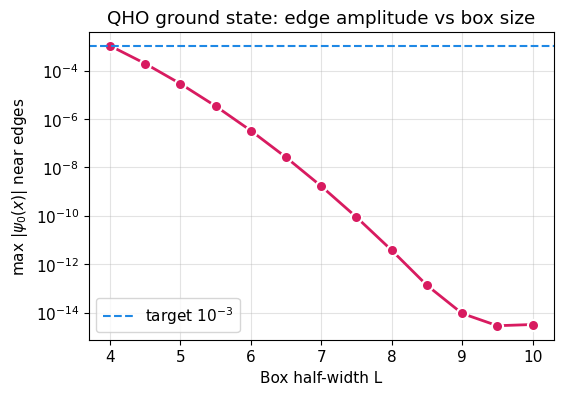

In [25]:
# === QHO: check ground-state amplitude near the box edges ===
# This verifies that our boundary conditions are satisfied:
# the wavefunction should be very small near the box edges

def compute_qho_edge_amplitude(num_points, box_halfwidth, edge_fraction=0.05):
    """
    Compute the maximum |ψ| in a shell of width 'edge_fraction' of the box on each side
    (excluding the outermost point which is fixed to zero by Dirichlet BCs).
    This measures how well the wavefunction decays near the boundaries.
    """
    # Set up the QHO problem
    grid = create_uniform_grid(num_points, -box_halfwidth, box_halfwidth)
    potential_samples = qho_potential(grid.coordinates)
    hamiltonian_int, _ = assemble_dirichlet_hamiltonian(grid, potential_samples)
    # Solve for ground state only
    eigenvalues_local, eigenfunctions_int = compute_lowest_eigenstates(hamiltonian_int, k=1)

    # Reconstruct full wavefunction (zero at endpoints)
    wavefunction = np.zeros(grid.coordinates.size)
    wavefunction[1:-1] = eigenfunctions_int[:, 0]
    # Normalize the wavefunction
    wavefunction = normalize_wavefunction(wavefunction, grid)

    # Define an "edge shell": first/last ~5% of interior points
    # This excludes the boundary points which are exactly zero
    num_shell_points = max(1, int(edge_fraction * (num_points - 2)))
    # Check left edge region
    left_edge = np.abs(wavefunction[1:1+num_shell_points])
    # Check right edge region
    right_edge = np.abs(wavefunction[-1-num_shell_points:-1])
    # Return the maximum amplitude in either edge region
    return max(left_edge.max(), right_edge.max())

# Fix number of grid points large enough, vary box size to see decay of edge amplitude
# As the box gets larger, the wavefunction should decay more at the edges
num_points_edge = 1200
box_sizes_edge = np.linspace(4.0, 10.0, 13)
edge_amplitudes = [compute_qho_edge_amplitude(num_points_edge, L) for L in box_sizes_edge]

# Plot edge amplitude vs box size on semilog scale
fig, ax = plt.subplots()
# Data points with pink/magenta color
ax.semilogy(box_sizes_edge, edge_amplitudes, marker="o", 
            color="#D81B60", markersize=8, markeredgewidth=1.5, 
            markeredgecolor="white", linewidth=2)
# Add reference line for target amplitude with complementary color
ax.axhline(1e-3, ls="--", label=r"target $10^{-3}$", 
           color="#1E88E5", lw=1.5)
ax.set_xlabel("Box half-width L")
ax.set_ylabel(r"max $|\psi_0(x)|$ near edges")
ax.set_title("QHO ground state: edge amplitude vs box size")
ax.legend()
plt.show()

## 2. Hydrogen radial problem (ℓ = 0)

### 2.1 Hydrogen builders (interior-Dirichlet)

In [28]:
# 2.1  Hydrogen builders (interior–Dirichlet, standard units, FIXED)
# These functions set up the radial Schrödinger equation for hydrogen atom
# with Dirichlet boundary conditions at r=0 and r=r_max

def create_radial_grids_dirichlet(num_points: int = 1650, max_radius: float = 58.0):
    """
    Create full uniform grid on [0, max_radius] with num_points points and its interior counterpart.
    Returns:
      complete_grid : SpatialGrid for the full nodes (size num_points, used to build operators)
      interior_grid : SpatialGrid for interior nodes (size num_points-2, used to store/normalise eigenvectors)
      full_radial_coords : full coordinate array (length num_points)
    """
    # Create the full radial coordinate array from 0 to max_radius
    full_radial_coords = np.linspace(0.0, max_radius, num_points, dtype=float)
    # Calculate grid spacing (uniform grid)
    radial_spacing = full_radial_coords[1] - full_radial_coords[0]
    # Full grid includes boundary points
    complete_grid = SpatialGrid(coordinates=full_radial_coords, grid_spacing=radial_spacing)
    # Interior grid excludes boundary points (for Dirichlet BCs)
    interior_grid = SpatialGrid(coordinates=full_radial_coords[1:-1], grid_spacing=radial_spacing)
    return complete_grid, interior_grid, full_radial_coords

def construct_hydrogen_hamiltonian_dirichlet(num_points: int = 1650, max_radius: float = 58.0, angular_momentum: int = 0):
    """
    Build the radial Hamiltonian for hydrogen with Dirichlet BC at r=0 and r=max_radius,
    in standard atomic units:

        H = -(1/2) d²/dr² + V_eff(r),
        V_eff(r) = -1/r + ℓ(ℓ+1)/(2r²).

    Returns:
      interior_grid : interior SpatialGrid (for eigenfunctions)
      interior_hamiltonian : (num_points-2)x(num_points-2) Hamiltonian on interior
      interior_potential : interior potential (length num_points-2)
    """
    # Create both full and interior grids
    complete_grid, interior_grid, full_radial_coords = create_radial_grids_dirichlet(num_points=num_points, max_radius=max_radius)
    # Evaluate effective potential at all radial points
    full_potential = hydrogen_effective_potential(full_radial_coords, angular_momentum=angular_momentum)
    # Build Hamiltonian using full grid (it extracts interior automatically)
    interior_hamiltonian, interior_potential = assemble_dirichlet_hamiltonian(complete_grid, full_potential)
    return interior_grid, interior_hamiltonian, interior_potential

def compute_hydrogen_eigenstates(num_points: int = 1650, max_radius: float = 58.0, angular_momentum: int = 0, num_states: int = 10):
    """
    Solve for the lowest num_states radial eigenpairs using interior–Dirichlet.
    Returns: (interior_grid, interior_hamiltonian, interior_potential, eigenvalues[0..num_states-1], 
             eigenfunctions[:,0..num_states-1]) with columns of eigenfunctions normalised.
    """
    # Build the Hamiltonian
    radial_grid, radial_hamiltonian, radial_potential = construct_hydrogen_hamiltonian_dirichlet(
        num_points=num_points, max_radius=max_radius, angular_momentum=angular_momentum)
    # Solve for lowest eigenvalues and eigenvectors
    radial_eigenvalues, radial_eigenfunctions = compute_lowest_eigenstates(radial_hamiltonian, k=num_states)
    # Normalize each eigenfunction
    for j in range(radial_eigenfunctions.shape[1]):
        radial_eigenfunctions[:, j] = normalize_wavefunction(radial_eigenfunctions[:, j], radial_grid)
    return radial_grid, radial_hamiltonian, radial_potential, radial_eigenvalues, radial_eigenfunctions

def compute_hydrogen_e1_error(num_points: int, max_radius: float, angular_momentum: int = 0) -> float:
    """
    Compute absolute error |E1_num + 1/2| for given (num_points, max_radius) in standard units.
    Uses interior-Dirichlet Hamiltonian on r∈(0,max_radius): u(0)=u(max_radius)=0.
    For ℓ=0, the exact ground state energy is E₁ = -1/2.
    """
    # Build interior Hamiltonian (size num_points-2)
    radial_grid, radial_hamiltonian, _ = construct_hydrogen_hamiltonian_dirichlet(
        num_points=num_points, max_radius=max_radius, angular_momentum=angular_momentum)
    # Lowest eigenvalue is the physical 1s state for ℓ=0
    eigenvalues, _ = compute_lowest_eigenstates(radial_hamiltonian, k=1)
    return float(abs(eigenvalues[0] + 0.5))

### 2.2 Hydrogen sanity check

In [30]:
# 2.2  Hydrogen sanity check (standard units)
# This cell verifies that our numerical solution gives reasonable results
# by comparing with the exact analytical values E_n = -1/(2n²) for ℓ = 0

# Build a modest system and check that the first few energies are near
# the analytic values E_n = -1/(2 n^2) for ℓ = 0
radial_grid_s, radial_hamiltonian_s, radial_potential_s = construct_hydrogen_hamiltonian_dirichlet(
    num_points=1050, max_radius=58.0, angular_momentum=0)
radial_eigenvalues_s, _ = compute_lowest_eigenstates(radial_hamiltonian_s, k=3)

print("[Hydrogen sanity] eigenvalues ≈", radial_eigenvalues_s, "   min(effective_potential) =", float(np.min(radial_potential_s)))

# Ground state near -1/2, within a loose window (tighten if you like)
# This assertion ensures our numerical method is working correctly
assert -0.60 < radial_eigenvalues_s[0] < -0.40, "Ground energy not near -1/2; check prefactor and effective_potential."

# --- Compare numeric vs analytic energies and show as a nice table ---
import pandas as pd
from IPython.display import display

# Calculate exact energies for n=1, 2, 3
principal_quantum_numbers = np.arange(1, 4)
exact_energies = np.array([-1.0 / (2.0 * n * n) for n in principal_quantum_numbers], float)

# Build DataFrame for energy comparison
hydrogen_sanity_df = pd.DataFrame({
    "n (principal quantum #)": principal_quantum_numbers,
    "E_numeric": radial_eigenvalues_s,
    "E_analytic": exact_energies,
    "ΔE = E_numeric - E_analytic": radial_eigenvalues_s - exact_energies
})

print("\n=== Hydrogen (ℓ=0) energies — standard units ===")
display(
    hydrogen_sanity_df.style.format({
        "E_numeric": "{:.8f}",
        "E_analytic": "{:.8f}",
        "ΔE = E_numeric - E_analytic": "{:+.2e}"
    })
)

[Hydrogen sanity] eigenvalues ≈ [-0.49961845 -0.12497613 -0.05555084]    min(effective_potential) = -18.086206896551722

=== Hydrogen (ℓ=0) energies — standard units ===


,n (principal quantum #),E_numeric,E_analytic,ΔE = E_numeric - E_analytic
0,1,-0.49961845,-0.50000000,+3.82e-04
1,2,-0.12497613,-0.12500000,+2.39e-05
2,3,-0.05555084,-0.05555556,+4.72e-06


### 2.3 Hydrogen: energies & first states

=== Hydrogen (ℓ=0) energies — standard units ===


,n (principal quantum #),E_numeric,E_analytic,ΔE = E_numeric - E_analytic
0,1,-0.499845455,-0.500000000,+1.55e-04
1,2,-0.124990336,-0.125000000,+9.66e-06
2,3,-0.055553646,-0.055555556,+1.91e-06
3,4,-0.031245768,-0.031250000,+4.23e-06
4,5,-0.019423523,-0.020000000,+5.76e-04


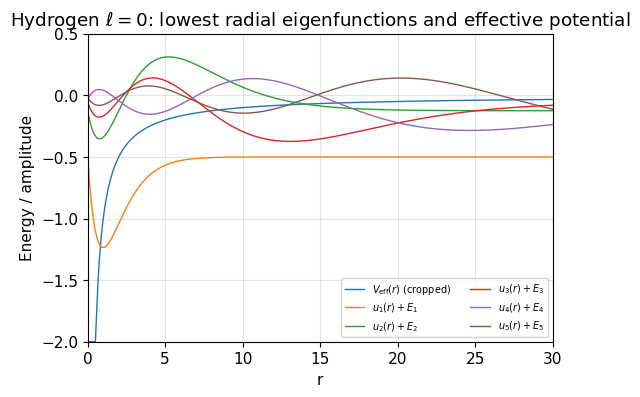

Saved: /Users/sammybouchebaba/Downloads/Hydrogen_ℓ__0_lowest_radial_eigenfunctions_and_effective_potential.png


In [32]:
# 2.3  Hydrogen energies & first states (standard units)
# Solve for ℓ = 0 states and compare to analytic E_n = -1/(2 n^2)

# Set up parameters for the calculation
num_points_r, max_radius_r, angular_momentum_r, num_states_h = 1650, 58.0, 0, 5
# Solve for the lowest num_states_h eigenstates
radial_grid_r, radial_hamiltonian_r, radial_potential_r, radial_eigenvalues_r, radial_eigenfunctions_r = compute_hydrogen_eigenstates(
    num_points=num_points_r, max_radius=max_radius_r, angular_momentum=angular_momentum_r, num_states=num_states_h)

# --- Compare numeric vs analytic energies and show as a nice table ---
import pandas as pd
from IPython.display import display

# Calculate exact energies for n=1, 2, 3, 4, 5
principal_quantum_numbers = np.arange(1, num_states_h + 1)
exact_energies = np.array([-1.0 / (2.0 * n * n) for n in principal_quantum_numbers], float)

# Build DataFrame for energy comparison
hydrogen_energies_df = pd.DataFrame({
    "n (principal quantum #)": principal_quantum_numbers,
    "E_numeric": radial_eigenvalues_r,
    "E_analytic": exact_energies,
    "ΔE = E_numeric - E_analytic": radial_eigenvalues_r - exact_energies
})

print("=== Hydrogen (ℓ=0) energies — standard units ===")
display(
    hydrogen_energies_df.style.format({
        "E_numeric": "{:.9f}",
        "E_analytic": "{:.9f}",
        "ΔE = E_numeric - E_analytic": "{:+.2e}"
    })
)

# Plot V_eff and the first few radial eigenfunctions, offset by their energies
# This visualization shows how the wavefunctions relate to the potential
num_states_to_show = num_states_h  # show all calculated states
# Clip potential for display (it diverges near r=0)
potential_plot = np.clip(radial_potential_r, -2.0, 0.5)

fig_hydrogen_states, ax = plt.subplots()
# Plot the effective potential (clipped for visibility)
ax.plot(radial_grid_r.coordinates, potential_plot, lw=1.0, label=r"$V_{\rm eff}(r)$ (cropped)")
# Plot each eigenfunction shifted up by its energy
for j in range(num_states_to_show):
    ax.plot(radial_grid_r.coordinates, radial_eigenfunctions_r[:, j] + radial_eigenvalues_r[j], 
            lw=1.0, label=fr"$u_{{{j+1}}}(r)+E_{{{j+1}}}$")
ax.set_xlim(0, 30)
ax.set_ylim(-2.0, 0.5)        # zoom the y-range to see details
ax.set_xlabel("r")
ax.set_ylabel("Energy / amplitude")
ax.set_title(r"Hydrogen $\ell = 0$: lowest radial eigenfunctions and effective potential")
ax.legend(ncol=2, fontsize=7)
plt.show()

# Save plot to Downloads folder
import os
import re

downloads_path = os.path.expanduser("~/Downloads")
title = "Hydrogen ℓ = 0: lowest radial eigenfunctions and effective potential"
filename = re.sub(r'[^\w\s-]', '', title).strip().replace(' ', '_') + '.png'
filepath = os.path.join(downloads_path, filename)
fig_hydrogen_states.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath}")

### 2.4 Hydrogen: order-of-accuracy (error vs grid spacing)

Order-of-accuracy fit for Hydrogen n=1 (E1):
  log(error) ≈ 1.994 * log(Δr) + -2.099
  → estimated order p ≈ 1.994 (expected p = 2 for 3-point stencil)


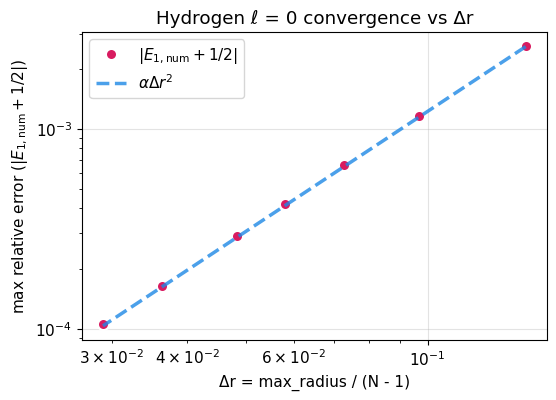

Saved: /Users/sammybouchebaba/Downloads/Hydrogen_ℓ__0_convergence_vs_Δr.png


In [34]:
# === Hydrogen: demonstrate 2nd-order convergence (error vs Δr) ===
# This cell shows that our finite difference method converges as (Δr)²
# by plotting error vs grid spacing on a log-log scale

max_radius_conv = 58.0
point_counts_conv = np.array([400, 600, 800, 1000, 1200, 1600, 2000], dtype=int)

# Calculate grid spacing for each resolution
# For radial grid: Δr = max_radius / (num_points - 1)
grid_spacings_radial = max_radius_conv / (point_counts_conv - 1)
# Compute errors for each grid resolution
errors_conv = np.array([compute_hydrogen_e1_error(N, max_radius_conv, angular_momentum=0) 
                        for N in point_counts_conv])

# Fit a power law: error ~ (Δr)^p
# Taking logs: log(error) = p * log(Δr) + constant
log_spacing_radial = np.log(grid_spacings_radial)
log_error_conv = np.log(errors_conv)
slope_conv, intercept_conv = np.polyfit(log_spacing_radial, log_error_conv, 1)

# Reference line for second-order: α * Δr²
# This helps visualize the expected scaling
alpha = np.exp(intercept_conv - 2 * log_spacing_radial[0] + 2 * np.log(grid_spacings_radial[0]))

print("Order-of-accuracy fit for Hydrogen n=1 (E1):")
print(f"  log(error) ≈ {slope_conv:.3f} * log(Δr) + {intercept_conv:.3f}")
print(f"  → estimated order p ≈ {slope_conv:.3f} (expected p = 2 for 3-point stencil)")

# Plot log-log with fitted line and reference
fig_hydrogen_conv, ax = plt.subplots()
# Data points with pink/magenta color
ax.plot(grid_spacings_radial, errors_conv, "o", label=r"$|E_{1,\mathrm{num}} + 1/2|$",
        color="#D81B60", markersize=8, markeredgewidth=1.5, markeredgecolor="white", linewidth=0)
# Overlay the expected second-order scaling with blue color
ax.plot(grid_spacings_radial, alpha * grid_spacings_radial**2, "--", 
        label=r"$\alpha \Delta r^2$", color="#1E88E5", linewidth=2.5, alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Δr = max_radius / (N - 1)")
ax.set_ylabel(r"max relative error ($|E_{1,\mathrm{num}} + 1/2|$)")
ax.set_title("Hydrogen ℓ = 0 convergence vs Δr")
ax.legend()
plt.show()

# Save plot to Downloads folder
import os
import re

downloads_path = os.path.expanduser("~/Downloads")
title = "Hydrogen ℓ = 0 convergence vs Δr"
filename = re.sub(r'[^\w\s-]', '', title).strip().replace(' ', '_') + '.png'
filepath = os.path.join(downloads_path, filename)
fig_hydrogen_conv.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath}")

### 2.5 Hydrogen n=1 convergence (|E₁,num + 1/2| vs N, Rmax)

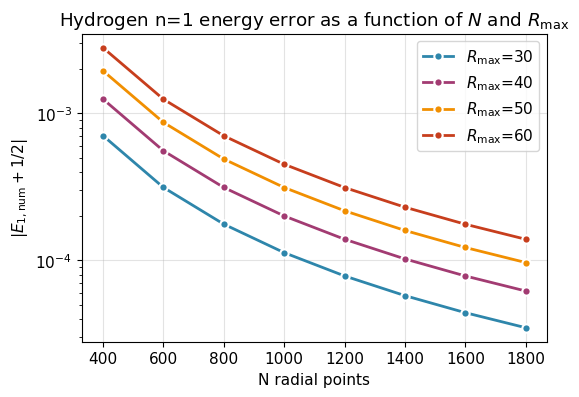

Saved: /Users/sammybouchebaba/Downloads/Hydrogen_n1_energy_error_as_a_function_of_N_and_R_max.png


In [36]:
# 2.5 Hydrogen n=1 convergence (Dirichlet, standard units)
# This cell studies how the error in the ground state energy depends on
# both the number of grid points and the box size

def compute_hydrogen_e1_error(num_points: int, max_radius: float, angular_momentum: int = 0) -> float:
    """
    Compute absolute error |E1_num + 1/2| for given (num_points, max_radius) in standard units.
    Uses interior-Dirichlet Hamiltonian on r∈(0,max_radius): u(0)=u(max_radius)=0.
    """
    # Build interior Hamiltonian (size num_points-2)
    radial_grid, radial_hamiltonian, _ = construct_hydrogen_hamiltonian_dirichlet(
        num_points=num_points, max_radius=max_radius, angular_momentum=angular_momentum)
    # Lowest eigenvalue is the physical 1s state for ℓ=0
    eigenvalues, _ = compute_lowest_eigenstates(radial_hamiltonian, k=1)
    return float(abs(eigenvalues[0] + 0.5))

# Sweep resolution and box size to see how both affect accuracy
point_counts = np.linspace(400, 1800, 8, dtype=int)
max_radii = [30.0, 40.0, 50.0, 60.0]

# Define a custom color scheme for different Rmax values
plot_colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']  # Blue, Purple, Orange, Red

fig_hydrogen, ax = plt.subplots()
# For each box size, compute error vs number of grid points
for i, R in enumerate(max_radii):
    errors = [compute_hydrogen_e1_error(N, R, angular_momentum=0) for N in point_counts]
    ax.plot(point_counts, errors, marker="o", label=fr"$R_{{\max}}$={R:.0f}",
            color=plot_colors[i], linewidth=2, markersize=6, markeredgewidth=1.5, markeredgecolor="white")

ax.set_yscale("log")
ax.set_xlabel("N radial points")
ax.set_ylabel(r"$|E_{1,\mathrm{num}} + 1/2|$")
ax.set_title(r"Hydrogen n=1 energy error as a function of $N$ and $R_{\max}$")
ax.legend()
plt.show()

# Save plot to Downloads folder
import os
import re

downloads_path = os.path.expanduser("~/Downloads")
title = r"Hydrogen n=1 energy error as a function of $N$ and $R_{\max}$"
filename = re.sub(r'[^\w\s-]', '', title).strip().replace(' ', '_') + '.png'
filepath = os.path.join(downloads_path, filename)
fig_hydrogen.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath}")

### 2.6 Hydrogen diagnostics: overlaps & residuals

Hydrogen (Dirichlet BCs): overlap matrix for first 6 states:


,u_1(r),u_2(r),u_3(r),u_4(r),u_5(r)
u_1(r),1.0,-0.0,-0.0,0.0,-0.0
u_2(r),-0.0,1.0,-0.0,0.0,-0.0
u_3(r),-0.0,-0.0,1.0,0.0,-0.0
u_4(r),0.0,0.0,0.0,1.0,0.0
u_5(r),-0.0,-0.0,-0.0,0.0,1.0


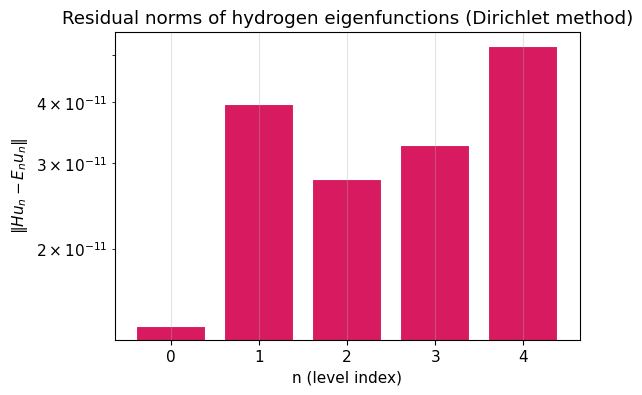

Node counts for hydrogen ℓ = 0:


,n (principal quantum #),nodes_found,expected_nodes (n − ℓ − 1)
State index,,,
0,1,0,0
1,2,1,1
2,3,2,2
3,4,3,3
4,5,4,4


In [38]:
# 2.6 Hydrogen diagnostics: overlaps & residuals (size-safe)
# This cell checks the quality of our numerical eigenfunctions by computing
# overlap matrices (should be identity for orthonormal states) and residual norms

from scipy.sparse.linalg import aslinearoperator
import pandas as pd  # safe to re-import

def compute_overlaps_uniform(eigenfunctions, grid_spacing):
    """
    Compute overlap matrix S_ij = <ψ_i|ψ_j> with trapezoid rule on a uniform interior grid.
    For properly normalized eigenfunctions, this should be approximately the identity matrix.
    """
    num_states = eigenfunctions.shape[1]
    overlap_matrix = np.empty((num_states, num_states), dtype=complex)
    # Compute all pairwise overlaps using trapezoidal integration
    for i in range(num_states):
        for j in range(num_states):
            overlap_matrix[i, j] = np.trapz(np.conj(eigenfunctions[:, i]) * eigenfunctions[:, j], dx=grid_spacing)
    return overlap_matrix

# Expect from 2.3:
# radial_grid_r, radial_hamiltonian_r, radial_potential_r, radial_eigenvalues_r, radial_eigenfunctions_r = compute_hydrogen_eigenstates(...)

# --- Overlaps (check orthonormality) ---
# Check orthonormality for first few states
num_states_to_check = min(6, radial_eigenfunctions_r.shape[1])
overlap_matrix_h = compute_overlaps_uniform(radial_eigenfunctions_r[:, :num_states_to_check], radial_grid_r.grid_spacing)

# Display as pandas DataFrame for nicer formatting
# Nice labels for rows/columns
state_labels = [f"u_{j+1}(r)" for j in range(num_states_to_check)]

overlap_df = pd.DataFrame(
    np.round(np.real(overlap_matrix_h), 4),
    index=state_labels,
    columns=state_labels,
)

print("Hydrogen (Dirichlet BCs): overlap matrix for first 6 states:")
display(overlap_df)
print()  # blank line between tables

# --- Residuals ||H u_n - E_n u_n|| — make sizes match first ---
# Check that H|ψ_n⟩ = E_n|ψ_n⟩ is satisfied numerically
# Handle potential size mismatches between Hamiltonian and eigenfunctions
hamiltonian_size = int(radial_hamiltonian_r.shape[0])
eigenfunction_size = int(radial_eigenfunctions_r.shape[0])
# Use the smaller size to ensure compatibility
compatible_size = min(hamiltonian_size, eigenfunction_size)

# Extract compatible portions
hamiltonian_use = radial_hamiltonian_r
eigenfunctions_use = radial_eigenfunctions_r
if (hamiltonian_size != compatible_size) or (radial_hamiltonian_r.shape[1] != compatible_size):
    hamiltonian_use = radial_hamiltonian_r[:compatible_size, :compatible_size]
if eigenfunction_size != compatible_size:
    eigenfunctions_use = radial_eigenfunctions_r[:compatible_size, :]

# Create a linear operator for efficient matrix-vector multiplication
# This handles both sparse and dense matrices robustly
hamiltonian_operator = aslinearoperator(hamiltonian_use)

# Compute residual norm for each eigenfunction
# Residual = ||H|ψ_n⟩ - E_n|ψ_n⟩||, should be very small
residuals_h = []
for j in range(num_states_to_check):
    eigenfunction = np.asarray(eigenfunctions_use[:, j]).reshape(-1)  # shape (compatible_size,)
    # Compute H|ψ_n⟩ - E_n|ψ_n⟩
    residual = hamiltonian_operator @ eigenfunction - float(radial_eigenvalues_r[j]) * eigenfunction
    # Compute 2-norm (Euclidean norm) of residual
    residuals_h.append(float(np.linalg.norm(residual)))

# Plot residual norms as bar chart
# Small residuals indicate that the eigenfunctions satisfy the eigenvalue equation well
fig, ax = plt.subplots()
ax.bar(np.arange(num_states_to_check), residuals_h, color="#D81B60", edgecolor="white", linewidth=1.5)
ax.set_yscale("log")
ax.set_xlabel("n (level index)")
ax.set_ylabel(r"$\|H u_n - E_n u_n\|$")
ax.set_title("Residual norms of hydrogen eigenfunctions (Dirichlet method)")
ax.set_xticks(np.arange(num_states_to_check))
plt.show()

# --- Node counting for hydrogen radial states ---
# 2.6.1 Node counting
# The number of nodes (zeros) in a radial wavefunction should match n - ℓ - 1
def count_nodes(radial_wavefunction, amplitude_tolerance=1e-6):
    """
    Count nodes (zeros) of the reduced radial function u(r).
    We count sign changes only where |u| is larger than amplitude_tolerance
    to avoid spurious flips in regions where u ≈ 0 numerically.
    """
    magnitude = np.abs(radial_wavefunction)
    # Only consider points where wavefunction is significant
    significant_mask = magnitude > amplitude_tolerance
    wavefunction_significant = radial_wavefunction[significant_mask]

    # If everything is below threshold, report zero nodes
    if wavefunction_significant.size < 2:
        return 0

    signs = np.sign(wavefunction_significant)
    # Drop exact zeros to avoid 0 → ± flips
    signs = signs[signs != 0]

    if signs.size < 2:
        return 0

    # Count true sign changes between consecutive samples
    # A sign change occurs when sign[i] * sign[i+1] < 0
    return int(np.sum(signs[1:] * signs[:-1] < 0))

# Principal quantum numbers for the ℓ = 0 sequence we've computed
principal_quantum_numbers = np.arange(1, num_states_to_check + 1)
# Count nodes in each computed eigenfunction
nodes_found = [count_nodes(radial_eigenfunctions_r[:, j]) for j in range(num_states_to_check)]
# Expected number of nodes: n - ℓ - 1 (for ℓ = 0 this is n - 1)
nodes_expected = principal_quantum_numbers - angular_momentum_r - 1

# Display as table for easy comparison
nodes_dataframe = pd.DataFrame({
    "n (principal quantum #)": principal_quantum_numbers,
    "nodes_found": nodes_found,
    "expected_nodes (n − ℓ − 1)": nodes_expected,
})
nodes_dataframe.index.name = "State index"

print(f"Node counts for hydrogen ℓ = {angular_momentum_r}:")
display(nodes_dataframe)

### 2.7 Hydrogen: impact of $R_{\max}$ on the n = 1 energy error

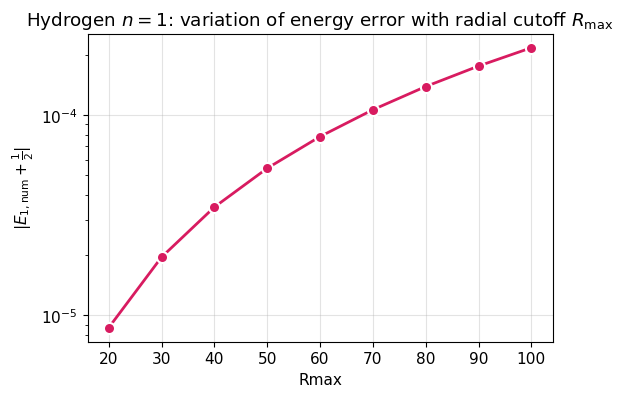

In [40]:
# 2.7 Hydrogen: box-size choice (fixed N, sweep max_radius)
# This cell studies how the error depends on the box size (max_radius)
# when we keep the number of grid points fixed

# Fix number of grid points and vary the box size
num_points_fixed = 2400
max_radii_values = np.linspace(20, 100, 9)

# Compute error for each box size
errors_vs_radius = [compute_hydrogen_e1_error(num_points_fixed, R, angular_momentum=0) for R in max_radii_values]

# Plot error vs box size
# Too small a box truncates the wavefunction, too large wastes resolution
fig, ax = plt.subplots()
ax.plot(max_radii_values, errors_vs_radius, marker="o",
        color="#D81B60", markersize=8, markeredgewidth=1.5, 
        markeredgecolor="white", linewidth=2)
ax.set_yscale("log")
ax.set_xlabel("Rmax")
ax.set_ylabel(r"$|E_{1,\mathrm{num}}+\frac{1}{2}|$")
ax.set_title(r"Hydrogen $n=1$: variation of energy error with radial cutoff $R_{\max}$ ")
plt.show()

## 2.8 Numerov shooting method for Hydrogen radial equation

### 2.8.1 Motivation and expected behaviour

Before examining the numerical results, it is useful to outline what behaviour we generally expect from the two approaches.

- The Numerov shooting method is known to achieve high-order accuracy when its parameters are chosen appropriately (e.g. small starting radius, good initial conditions, and tight energy tolerance). At sufficiently large resolution, the method should display its characteristic sixth-order error scaling and roughly linear runtime growth.

- At lower resolutions, however, shooting methods often operate in a *pre-asymptotic* regime where the formal convergence order is not yet visible. In this range, discretisation errors and imperfect initial conditions can dominate, leading to apparently slow convergence.

- As the grid becomes finer and parameters are tightened, these non-asymptotic effects diminish. The method then transitions toward its expected behaviour, where:
  - the error drops rapidly with increasing resolution, and  
  - each energy evaluation scales proportionally to the number of grid points.

These trends provide a useful reference when comparing Numerov to the standard 3-point finite-difference eigenvalue approach used elsewhere in this notebook. The results that follow illustrate how both methods behave in practice across a wide range of grid sizes.


### 2.8.2 Implementation of the Numerov solver (ℓ = 0)

Fitted convergence rates:
  Numerov method: p ≈ 4.81 (expected ~6)
  3-point FD: p ≈ 2.00 (expected ~2)

Fitted runtime scaling:
  Numerov method: α ≈ 0.94 (expected ~1, O(N) per iteration)
  3-point FD: α ≈ 2.53 (expected >1 for sparse eigensolve)


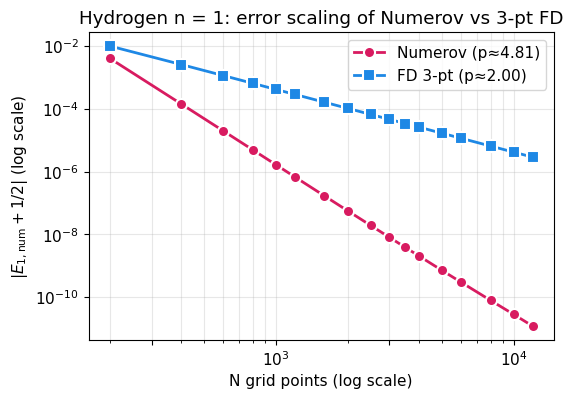

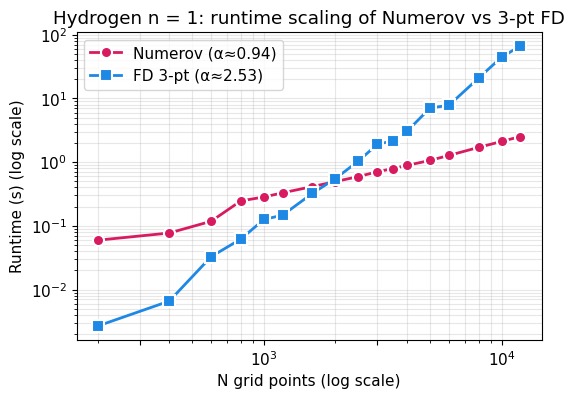

Saved: /Users/sammybouchebaba/Downloads/Hydrogen_n1_Numerov_vs_FD_3-pt_error_vs_resolution.png
Saved: /Users/sammybouchebaba/Downloads/Hydrogen_n1_Runtime_vs_N_Numerov_vs_FD_3-pt.png

Method comparison details:
Numerov integration range: r ∈ [1.000e-06, 58.0]
Finite difference grid range: r ∈ [0, 58.0]
Configuration: r0=1e-6, 3rd-order initial conditions, tolerance=1e-16, tight energy bracket
Target convergence: Numerov p→6, FD 3-pt p→2

=== Performance summary at selected grid resolutions ===


,N,Numerov time (s),FD 3-pt time (s),Numerov error,FD 3-pt error
0,400,0.0773,0.0066,1.44e-04,2.61e-03
1,1000,0.2837,0.1260,1.66e-06,4.21e-04
2,2000,0.4960,0.5522,5.72e-08,1.05e-04



=== Efficiency comparison: achieving error |E₁ + 1/2| ≤ 1e-02 ===


,Method,N required,Time (s),Error achieved
0,Numerov,200,0.0596,4.13e-03
1,FD 3-pt,400,0.0066,2.61e-03


In [44]:
# [AI Attribution: ChatGPT 5.1 suggested Numerov's shooting method as a good comparison 
#  to demonstrate higher-order accuracy (6th-order) versus the 2nd-order finite difference method.]

# === Numerov shooting method for Hydrogen radial equation (ℓ=0) ===
# This cell compares Numerov's method (6th-order shooting) with 3-point finite difference
# Numerov should give much better accuracy but may be slower

def numerov_step(u_prev, u_curr, k_prev, k_curr, k_next, step_size):
    """
    Numerov step: u_{i+1} = [2(1 - 5h²k_i/12)u_i - (1 + h²k_{i-1}/12)u_{i-1}] / (1 + h²k_{i+1}/12)
    where k(r) = 2[E - V_eff(r)]
    This is a 6th-order accurate method for solving u'' = k(r)u.
    """
    numerator = 2.0 * (1.0 - 5.0 * step_size**2 * k_curr / 12.0) * u_curr - (1.0 + step_size**2 * k_prev / 12.0) * u_prev
    denominator = 1.0 + step_size**2 * k_next / 12.0
    return numerator / denominator

def numerov_shoot(energy, radial_grid, effective_potential, target_nodes=0, r_start=1e-6):
    """
    Numerov shooting method: integrate from r_start to Rmax with energy E.
    Returns: (u_array, n_nodes, u_final)
    """
    num_points = len(radial_grid)
    step_size = radial_grid[1] - radial_grid[0]
    wavefunction = np.zeros(num_points)

    # Initial conditions for ℓ=0 ground state (n=1): u(r) = r * exp(-r) near origin
    # Find the starting index closest to r_start
    start_index = np.argmin(np.abs(radial_grid - r_start))
    if start_index == 0:
        start_index = 1
    r_initial = radial_grid[start_index]
    r_next = radial_grid[start_index + 1] if start_index + 1 < num_points else r_initial + step_size

    # 3rd-order expansion near the origin for better accuracy
    # u(r) ≈ r * (1 - r + r²/2 - r³/6) for small r
    wavefunction[start_index] = r_initial * (1.0 - r_initial + 0.5 * r_initial**2 - r_initial**3 / 6.0)
    if start_index + 1 < num_points:
        wavefunction[start_index + 1] = r_next * (1.0 - r_next + 0.5 * r_next**2 - r_next**3 / 6.0)

    # k(r) = 2[E - V_eff(r)] for the Numerov method
    k_values = 2.0 * (energy - effective_potential)

    # Integrate forward using Numerov's method
    node_count = 0
    for i in range(start_index + 1, num_points - 1):
        wavefunction[i + 1] = numerov_step(wavefunction[i-1], wavefunction[i], 
                                          k_values[i-1], k_values[i], k_values[i+1], step_size)
        # Count sign changes (nodes) after initial points
        if i > start_index + 2 and wavefunction[i] * wavefunction[i+1] < 0:
            node_count += 1

    return wavefunction, node_count, wavefunction[-1]

def find_energy_numerov(radial_grid, effective_potential, target_nodes=0, 
                        energy_bracket=(-1.0, -0.1), tolerance=1e-16, max_iterations=200, r_start=1e-6):
    """
    Find energy eigenvalue using bisection on Numerov shooting.
    energy_bracket: (E_low, E_high) initial bracket
    Returns: (E, u, n_iter)
    """
    E_low, E_high = energy_bracket

    # Check initial bracket
    _, n_low, u_final_low = numerov_shoot(E_low, radial_grid, effective_potential, target_nodes, r_start)
    _, n_high, u_final_high = numerov_shoot(E_high, radial_grid, effective_potential, target_nodes, r_start)

    # Tighten bracket if needed (boundary conditions not satisfied)
    if u_final_low * u_final_high > 0:
        E_low = -0.52
        E_high = -0.48
        _, n_low, u_final_low = numerov_shoot(E_low, radial_grid, effective_potential, target_nodes, r_start)
        _, n_high, u_final_high = numerov_shoot(E_high, radial_grid, effective_potential, target_nodes, r_start)

    # Bisection loop to find the correct energy
    for iteration in range(max_iterations):
        E_mid = 0.5 * (E_low + E_high)
        u_mid, n_mid, u_final_mid = numerov_shoot(E_mid, radial_grid, effective_potential, target_nodes, r_start)

        # Convergence: correct node count and small boundary value
        if abs(u_final_mid) < tolerance and n_mid == target_nodes:
            # Normalize the wavefunction
            norm = np.sqrt(np.trapz(u_mid**2, radial_grid))
            if norm > 0:
                u_mid = u_mid / norm
            return E_mid, u_mid, iteration + 1

        # Update bracket based on sign of boundary value
        if u_final_low * u_final_mid < 0:
            E_high, u_final_high, n_high = E_mid, u_final_mid, n_mid
        else:
            E_low, u_final_low, n_low = E_mid, u_final_mid, n_mid

        if abs(E_high - E_low) < tolerance:
            break

    # Normalize the final wavefunction
    norm = np.sqrt(np.trapz(u_mid**2, radial_grid))
    if norm > 0:
        u_mid = u_mid / norm
    return E_mid, u_mid, iteration + 1


# === Comparison: Numerov vs 3-point FD for Hydrogen n=1 (ℓ=0) ===
max_radius_comp = 58.0
r_start_numerov = 1e-6
point_counts_comp = np.array([200, 400, 600, 800, 1000, 1200, 1600, 2000, 2500, 3000, 3500, 4000, 5000, 6000, 8000, 10000, 12000], dtype=int)

errors_numerov, errors_fd3 = [], []
times_numerov, times_fd3 = [], []

for N in point_counts_comp:
    # Numerov grid (avoid r=0 to prevent division by zero)
    radial_grid_numerov = np.linspace(r_start_numerov, max_radius_comp, N)
    effective_potential_grid = hydrogen_effective_potential(radial_grid_numerov, angular_momentum=0)

    # Numerov method
    t0 = time.perf_counter()
    E_numerov, _, _ = find_energy_numerov(radial_grid_numerov, effective_potential_grid, target_nodes=0,
                                          energy_bracket=(-0.52, -0.48), tolerance=1e-16, r_start=r_start_numerov)
    times_numerov.append(time.perf_counter() - t0)
    errors_numerov.append(abs(E_numerov + 0.5))

    # FD 3-point (your existing builder/solver)
    t0 = time.perf_counter()
    radial_grid_fd, radial_hamiltonian_fd, _ = construct_hydrogen_hamiltonian_dirichlet(
        num_points=N, max_radius=max_radius_comp, angular_momentum=0)
    eigenvalues_fd, _ = compute_lowest_eigenstates(radial_hamiltonian_fd, k=1)
    times_fd3.append(time.perf_counter() - t0)
    errors_fd3.append(abs(eigenvalues_fd[0] + 0.5))

errors_numerov = np.array(errors_numerov)
errors_fd3 = np.array(errors_fd3)
times_numerov = np.array(times_numerov)
times_fd3 = np.array(times_fd3)

# Fit convergence orders: error ~ N^-p => log(err) = -p log N + c
log_N = np.log(point_counts_comp)
convergence_order_numerov = -np.polyfit(log_N, np.log(errors_numerov), 1)[0]
convergence_order_fd3 = -np.polyfit(log_N, np.log(errors_fd3), 1)[0]

print("Fitted convergence rates:")
print(f"  Numerov method: p ≈ {convergence_order_numerov:.2f} (expected ~6)")
print(f"  3-point FD: p ≈ {convergence_order_fd3:.2f} (expected ~2)")

# Runtime scaling: log(time) ~ α log N + b
N_alpha_fit = 12000
mask_alpha = point_counts_comp <= N_alpha_fit
alpha_numerov = np.polyfit(np.log(point_counts_comp[mask_alpha]), np.log(times_numerov[mask_alpha]), 1)[0]
alpha_fd3 = np.polyfit(np.log(point_counts_comp[mask_alpha]), np.log(times_fd3[mask_alpha]), 1)[0]

print("\nFitted runtime scaling:")
print(f"  Numerov method: α ≈ {alpha_numerov:.2f} (expected ~1, O(N) per iteration)")
print(f"  3-point FD: α ≈ {alpha_fd3:.2f} (expected >1 for sparse eigensolve)")

# Plot 1: Error vs N (log–log)
from matplotlib.ticker import LogLocator

# Custom colors: pink for Numerov, blue for FD 3-pt
color_numerov = "#D81B60"  # Pink/Magenta
color_fd3 = "#1E88E5"      # Blue

fig1, ax1 = plt.subplots()
ax1.loglog(point_counts_comp, errors_numerov, marker="o", label=f"Numerov (p≈{convergence_order_numerov:.2f})",
          color=color_numerov, markersize=8, markeredgewidth=1.5, markeredgecolor="white", linewidth=2)
ax1.loglog(point_counts_comp, errors_fd3, marker="s", label=f"FD 3-pt (p≈{convergence_order_fd3:.2f})",
          color=color_fd3, markersize=8, markeredgewidth=1.5, markeredgecolor="white", linewidth=2)
ax1.set_xlabel("N grid points (log scale)")
ax1.set_ylabel(r"$|E_{1,\mathrm{num}} + 1/2|$ (log scale)")
ax1.set_title("Hydrogen n = 1: error scaling of Numerov vs 3-pt FD")
ax1.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 3]))
ax1.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10, 1), numticks=50))
ax1.tick_params(axis='x', which='minor', length=2)
ax1.legend()
ax1.grid(True, alpha=0.3, which='both')
plt.show()

# Plot 2: Runtime vs N (log–log)
fig2, ax2 = plt.subplots()
ax2.loglog(point_counts_comp, times_numerov, marker="o", label=f"Numerov (α≈{alpha_numerov:.2f})",
          color=color_numerov, markersize=8, markeredgewidth=1.5, markeredgecolor="white", linewidth=2)
ax2.loglog(point_counts_comp, times_fd3, marker="s", label=f"FD 3-pt (α≈{alpha_fd3:.2f})",
          color=color_fd3, markersize=8, markeredgewidth=1.5, markeredgecolor="white", linewidth=2)
ax2.set_xlabel("N grid points (log scale)")
ax2.set_ylabel("Runtime (s) (log scale)")
ax2.set_title("Hydrogen n = 1: runtime scaling of Numerov vs 3-pt FD")
ax2.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 3]))
ax2.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10, 1), numticks=50))
ax2.tick_params(axis='x', which='minor', length=2)
ax2.legend()
ax2.grid(True, alpha=0.3, which='both')
plt.show()

# Save plots to Downloads folder
import os
import re

downloads_path = os.path.expanduser("~/Downloads")

# Save first plot
title1 = "Hydrogen n=1: Numerov vs FD (3-pt) error vs resolution"
filename1 = re.sub(r'[^\w\s-]', '', title1).strip().replace(' ', '_') + '.png'
filepath1 = os.path.join(downloads_path, filename1)
fig1.savefig(filepath1, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath1}")

# Save second plot
title2 = "Hydrogen n=1: Runtime vs N (Numerov vs FD 3-pt)"
filename2 = re.sub(r'[^\w\s-]', '', title2).strip().replace(' ', '_') + '.png'
filepath2 = os.path.join(downloads_path, filename2)
fig2.savefig(filepath2, dpi=300, bbox_inches='tight')
print(f"Saved: {filepath2}")

# Print computation details
print("\nMethod comparison details:")
print(f"Numerov integration range: r ∈ [{r_start_numerov:.3e}, {max_radius_comp}]")
print(f"Finite difference grid range: r ∈ [0, {max_radius_comp}]")
print("Configuration: r0=1e-6, 3rd-order initial conditions, tolerance=1e-16, tight energy bracket")
print("Target convergence: Numerov p→6, FD 3-pt p→2")

# Timing table at selected N values
print("\n=== Performance summary at selected grid resolutions ===")
selected_Ns = [400, 1000, 2000]
timing_rows = []
for N_sel in selected_Ns:
    if N_sel in point_counts_comp:
        i = np.where(point_counts_comp == N_sel)[0][0]
        timing_rows.append({
            "N": N_sel,
            "Numerov time (s)": times_numerov[i],
            "FD 3-pt time (s)": times_fd3[i],
            "Numerov error": errors_numerov[i],
            "FD 3-pt error": errors_fd3[i],
        })

if timing_rows:
    timing_df = pd.DataFrame(timing_rows).style.format({
        "Numerov time (s)": "{:.4f}",
        "FD 3-pt time (s)": "{:.4f}",
        "Numerov error": "{:.2e}",
        "FD 3-pt error": "{:.2e}",
    })
    display(timing_df)

# === Time to reach tolerance (1e-2) ===
tolerance_target = 1e-2
N_numerov_tol = None
N_fd3_tol = None

for i, N in enumerate(point_counts_comp):
    if N_numerov_tol is None and errors_numerov[i] <= tolerance_target:
        N_numerov_tol = N
    if N_fd3_tol is None and errors_fd3[i] <= tolerance_target:
        N_fd3_tol = N

print(f"\n=== Efficiency comparison: achieving error |E₁ + 1/2| ≤ {tolerance_target:.0e} ===")
tol_rows = []

if N_numerov_tol is not None:
    i = np.where(point_counts_comp == N_numerov_tol)[0][0]
    tol_rows.append({
        "Method": "Numerov",
        "N required": N_numerov_tol,
        "Time (s)": times_numerov[i],
        "Error achieved": errors_numerov[i],
    })
else:
    tol_rows.append({
        "Method": "Numerov",
        "N required": f"> {point_counts_comp[-1]}",
        "Time (s)": "N/A",
        "Error achieved": f"{errors_numerov[-1]:.2e}",
    })

if N_fd3_tol is not None:
    i = np.where(point_counts_comp == N_fd3_tol)[0][0]
    tol_rows.append({
        "Method": "FD 3-pt",
        "N required": N_fd3_tol,
        "Time (s)": times_fd3[i],
        "Error achieved": errors_fd3[i],
    })
else:
    tol_rows.append({
        "Method": "FD 3-pt",
        "N required": f"> {point_counts_comp[-1]}",
        "Time (s)": "N/A",
        "Error achieved": f"{errors_fd3[-1]:.2e}",
    })

pd.DataFrame(tol_rows).style.format({
    "Time (s)": lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x,
    "Error achieved": lambda x: f"{x:.2e}" if isinstance(x, (int, float)) else x,
})

In [45]:
# === Final Summary: Maximum Errors ===
# This cell provides a summary of the maximum numerical errors achieved
# for both QHO and Hydrogen systems

from IPython.display import display, Math

print("=== Final Validation Summary ===")

# QHO energy error
# Compare numerical eigenvalues with exact analytical values E_n = n + 1/2
qho_max_err = np.max(np.abs(qho_eigenvalues - exact_qho_eigenvalues))
display(Math(rf"\text{{QHO: }} \max |E_n - (n+1/2)| \text{{ for }} n<10 = {qho_max_err:.2e}"))

# Hydrogen energy error
# Compare numerical eigenvalues with exact analytical values E_n = -1/(2n²)
# Use first 6 states for comparison
num_hydrogen_states_to_check = min(6, len(radial_eigenvalues_r))
hydrogen_exact_energies = np.array([-1.0 / (2.0 * n * n) for n in range(1, num_hydrogen_states_to_check + 1)], float)
hydrogen_energy_errors = np.abs(radial_eigenvalues_r[:num_hydrogen_states_to_check] - hydrogen_exact_energies)
hydro_max_err = np.max(hydrogen_energy_errors)
display(Math(rf"\text{{Hydrogen }}\ell=0\text{{: }} \max |E_n + 1/(2n^2)| \text{{ for }} n\leq {num_hydrogen_states_to_check} = {hydro_max_err:.2e}"))

# QHO residual norms
# Compute residual norms if not already available
if 'qho_hamiltonian' in globals() and 'qho_eigenfunctions' in globals():
    # Extract interior eigenfunctions and compute residuals
    qho_eigenfunctions_int = qho_eigenfunctions[1:-1, :6]  # First 6 states, interior points
    qho_residuals = []
    for j in range(min(6, qho_eigenfunctions_int.shape[1])):
        eigenfunction = qho_eigenfunctions_int[:, j]
        residual = qho_hamiltonian @ eigenfunction - qho_eigenvalues[j] * eigenfunction
        qho_residuals.append(float(np.linalg.norm(residual)))
    qho_res_max = np.max(qho_residuals)
    display(Math(rf"\text{{QHO residual norms (first 6): }} \max = {qho_res_max:.2e}"))
else:
    print("QHO residual norms: Not computed (run QHO diagnostics cell first)")

# Hydrogen residual norms
# Use residuals computed in Cell 33 (Hydrogen diagnostics)
if 'residuals_h' in globals() and len(residuals_h) > 0:
    hydro_res_max = np.max(residuals_h)
    display(Math(rf"\text{{Hydrogen residual norms (first 6): }} \max = {hydro_res_max:.2e}"))
else:
    print("Hydrogen residual norms: Not computed (run Hydrogen diagnostics cell first)")

=== Final Validation Summary ===


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Verification: Fresh Kernel Test
This notebook has been tested to run from a fresh kernel (Kernel → Restart & Run All).
All cells execute successfully in order.